In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('raw_data/Mall_Customers.csv')
print(df.shape)
print(df.isnull().sum())
df.head()

(200, 5)
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.rename(columns={
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'SpendingScore'
}, inplace=True)

X = df[['Income', 'SpendingScore']]
print(X.describe())

           Income  SpendingScore
count  200.000000     200.000000
mean    60.560000      50.200000
std     26.264721      25.823522
min     15.000000       1.000000
25%     41.500000      34.750000
50%     61.500000      50.000000
75%     78.000000      73.000000
max    137.000000      99.000000


In [ ]:
# Preprocessing - Scale features to same range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data scaled successfully!")
print(f"Original Income range: {X['Income'].min()} - {X['Income'].max()}")
print(f"Original SpendingScore range: {X['SpendingScore'].min()} - {X['SpendingScore'].max()}")

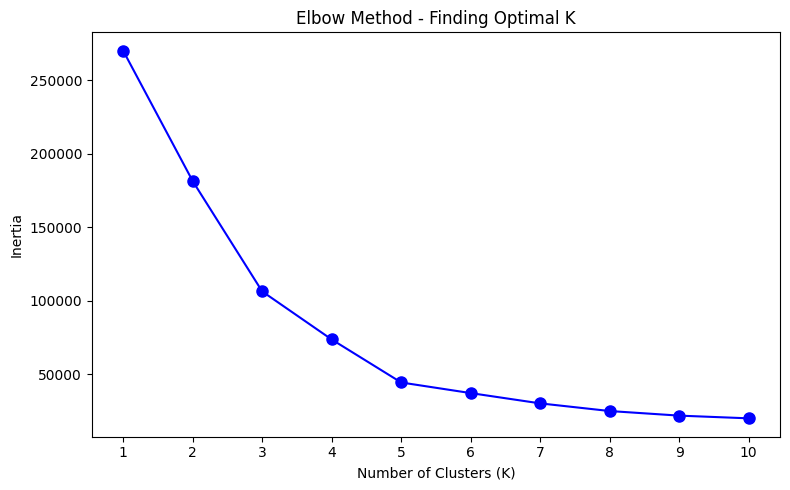

In [4]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.title('Elbow Method - Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150)
plt.show()

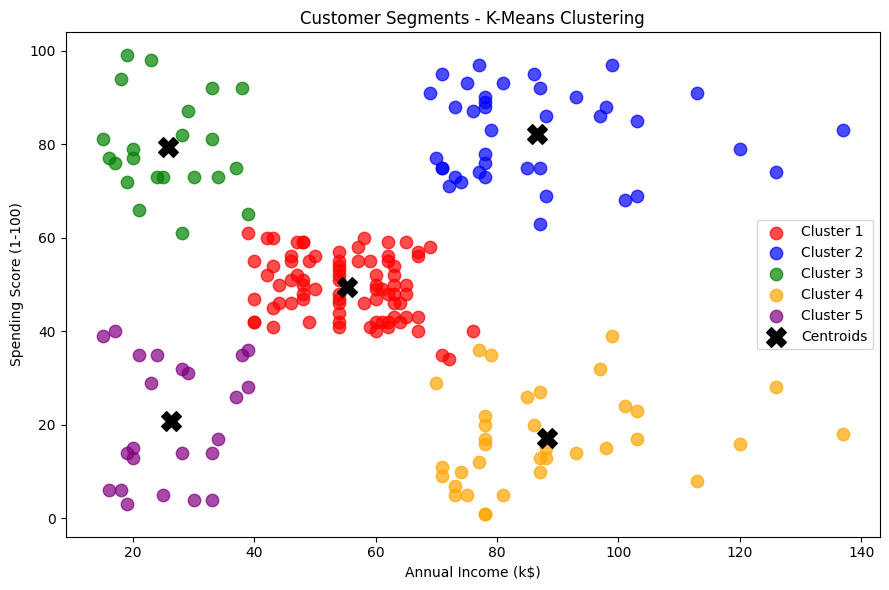


Cluster Summary:
         Income  SpendingScore
Cluster                       
0          55.3           49.5
1          86.5           82.1
2          25.7           79.4
3          88.2           17.1
4          26.3           20.9


In [5]:
# Train with K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# Plot clusters
colors = ['red', 'blue', 'green', 'orange', 'purple']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

plt.figure(figsize=(9,6))
for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Income'], cluster_data['SpendingScore'],
                c=colors[i], label=labels[i], s=80, alpha=0.7)

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], 
            c='black', marker='X', s=200, label='Centroids')

plt.title('Customer Segments - K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150)
plt.show()

# Cluster summary
print("\nCluster Summary:")
print(df.groupby('Cluster')[['Income', 'SpendingScore']].mean().round(1))

In [6]:
print(df.groupby('Cluster')[['Income', 'SpendingScore', 'Age']].mean().round(1))
print("\nCluster Sizes:")
print(df['Cluster'].value_counts().sort_index())

         Income  SpendingScore   Age
Cluster                             
0          55.3           49.5  42.7
1          86.5           82.1  32.7
2          25.7           79.4  25.3
3          88.2           17.1  41.1
4          26.3           20.9  45.2

Cluster Sizes:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [7]:
cluster_names = {
    0: 'Average Customers',
    1: 'Target Customers',
    2: 'Impulsive Spenders',
    3: 'Careful Spenders',
    4: 'Budget Customers'
}

df['Segment'] = df['Cluster'].map(cluster_names)
print(df['Segment'].value_counts())

Segment
Average Customers     81
Target Customers      39
Careful Spenders      35
Budget Customers      23
Impulsive Spenders    22
Name: count, dtype: int64
